# Bilateral Filtering

- (a) Manually implement bilateral filter for grayscale images
- (b) Apply Gaussian smoothing using OpenCV
- (c) Apply bilateral filtering using OpenCV
- (d) Apply manually implemented bilateral filter.

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt

%matplotlib inline


## (a) Manual Implementation of Bilateral Filter

In [2]:
def bilateral_filter_manual(img, diameter, sigma_s, sigma_r):
    # Ensure diameter is odd
    if diameter % 2 == 0:
        diameter += 1
    
    # Calculate radius
    radius = diameter // 2
    
    # Get image dimensions
    h, w = img.shape
    
    # Initialize output image
    filtered_img = np.zeros_like(img, dtype=np.float64)
    
    # Pad image to handle borders
    img_padded = np.pad(img, radius, mode='edge')
    
    # Pre-compute spatial Gaussian weights
    spatial_weights = np.zeros((diameter, diameter))
    for i in range(diameter):
        for j in range(diameter):
            # Distance from center
            di = i - radius
            dj = j - radius
            spatial_dist = sqrt(di**2 + dj**2)
            # Spatial Gaussian weight
            spatial_weights[i, j] = exp(-(spatial_dist**2) / (2 * sigma_s**2))
    
    # Apply bilateral filter
    for i in range(h):
        for j in range(w):
            # Get center pixel value
            center_pixel = img_padded[i + radius, j + radius]
            
            # Initialize weighted sum and normalization factor
            weighted_sum = 0.0
            normalization = 0.0
            
            # Process neighborhood
            for ki in range(diameter):
                for kj in range(diameter):
                    # Get neighbor pixel value
                    neighbor_pixel = img_padded[i + ki, j + kj]
                    
                    # Calculate intensity difference
                    intensity_diff = abs(float(neighbor_pixel) - float(center_pixel))
                    
                    # Range (intensity) Gaussian weight
                    range_weight = exp(-(intensity_diff**2) / (2 * sigma_r**2))
                    
                    # Combined bilateral weight
                    bilateral_weight = spatial_weights[ki, kj] * range_weight
                    
                    # Accumulate weighted sum
                    weighted_sum += bilateral_weight * neighbor_pixel
                    normalization += bilateral_weight
            
            # Normalize and store result
            filtered_img[i, j] = weighted_sum / normalization
        
        # Progress indicator (every 10%)
        if (i + 1) % max(1, h // 10) == 0:
            print(f"Progress: {(i + 1) * 100 // h}%")
    
    # Convert back to uint8
    filtered_img = np.clip(filtered_img, 0, 255).astype(np.uint8)
    
    return filtered_img

print("Bilateral filter function defined successfully")


Bilateral filter function defined successfully


## Load Test Image

Image size: (380, 364)
Data type: uint8


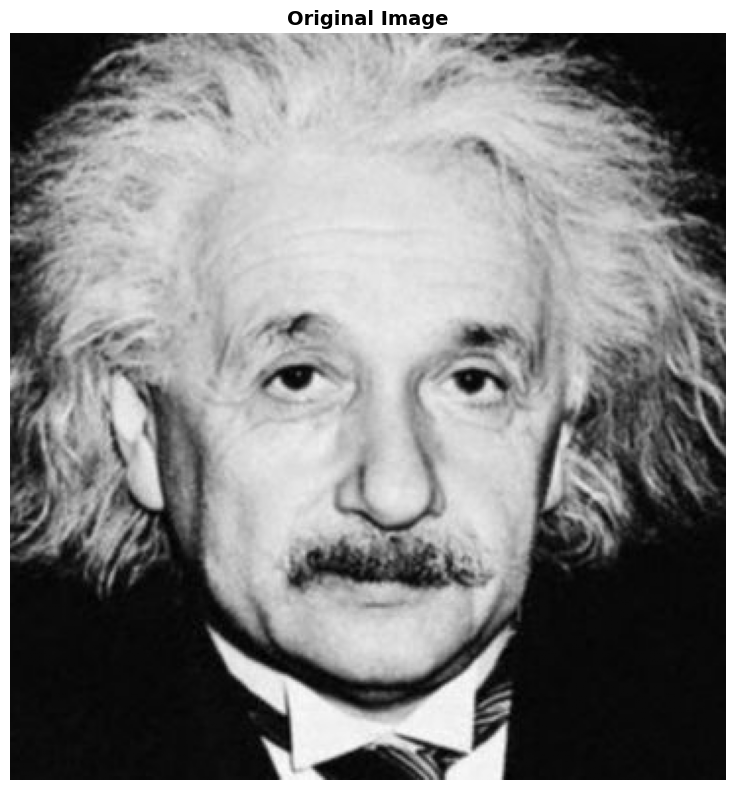

In [ ]:
# Load Image
img = cv2.imread('img/einstein.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("einstein.png not found")

print(f"Image size: {img.shape}")
print(f"Data type: {img.dtype}")

# Display original image
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


## (b) Gaussian Smoothing using OpenCV

Gaussian filtered image size: (380, 364)


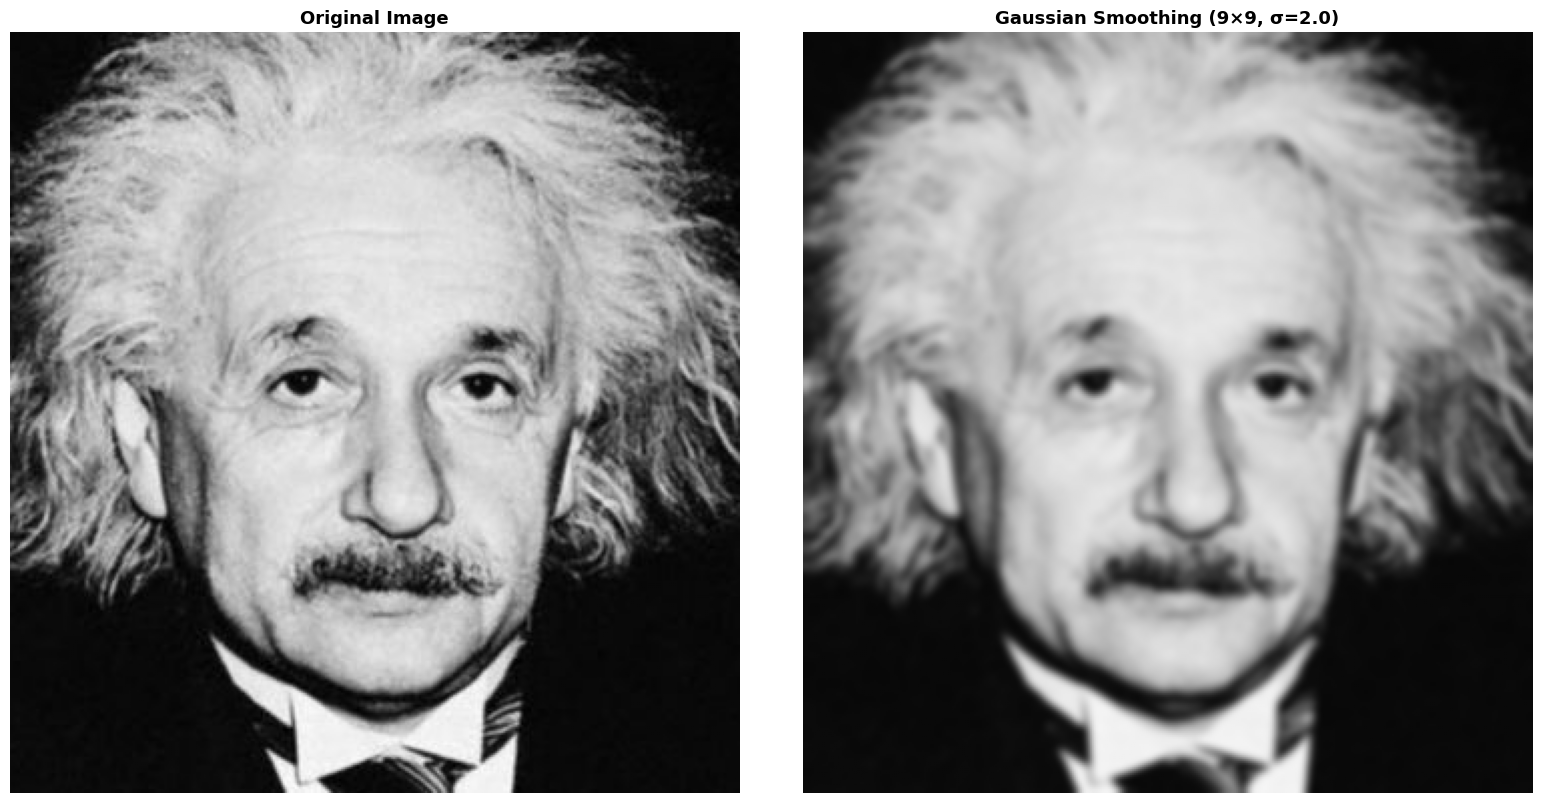

In [7]:
# Apply Gaussian smoothing
# Using kernel size 9x9 and sigma=2.0
img_gaussian = cv2.GaussianBlur(img, (9, 9), 2.0)

print(f"Gaussian filtered image size: {img_gaussian.shape}")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Gaussian Smoothing (9×9, σ=2.0)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## (c) Bilateral Filtering using OpenCV

Bilateral filtered image size: (380, 364)


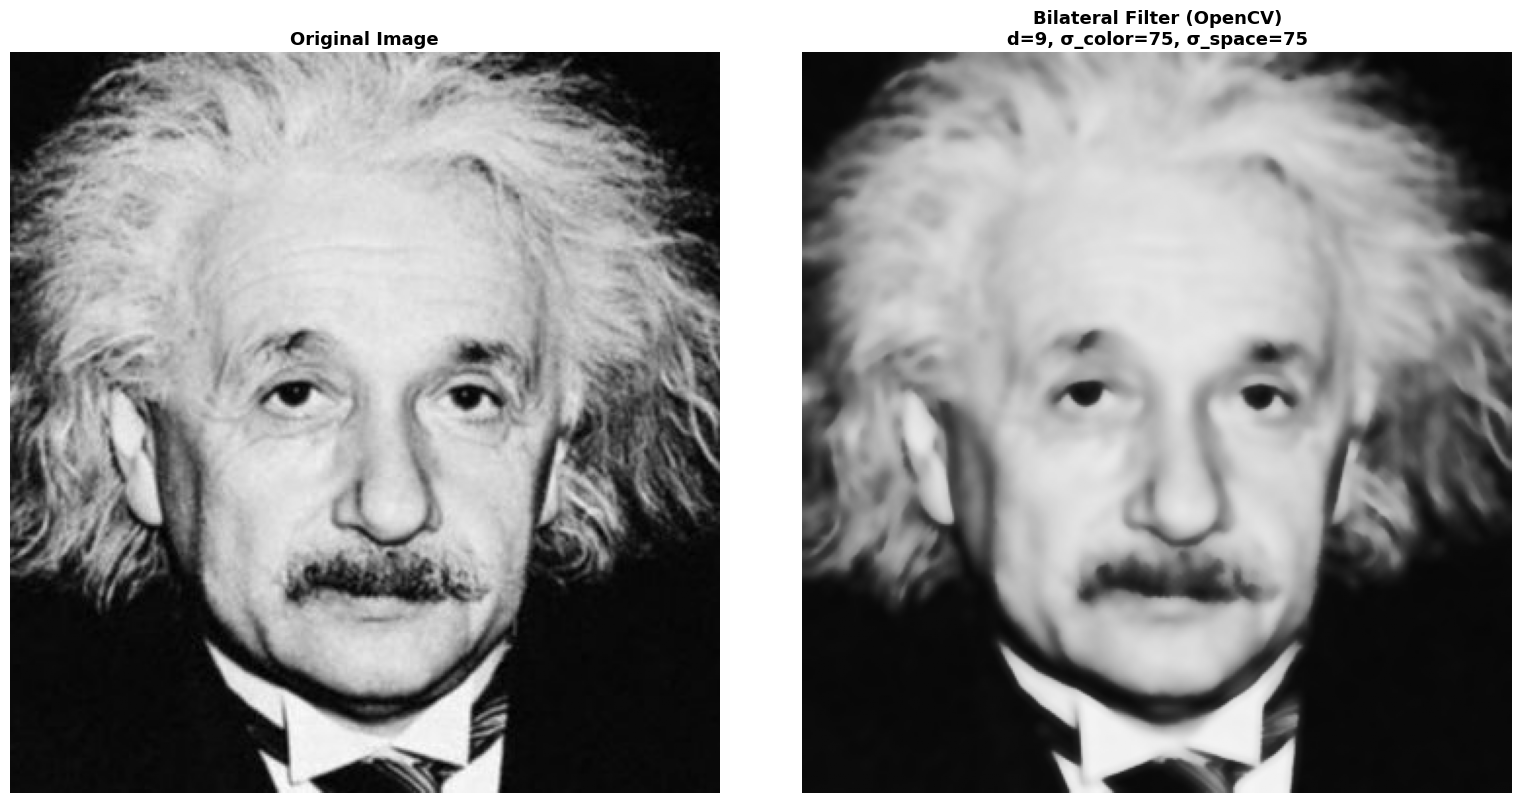

In [8]:
# Apply bilateral filtering using OpenCV
img_bilateral_cv = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

print(f"Bilateral filtered image size: {img_bilateral_cv.shape}")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_bilateral_cv, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Bilateral Filter (OpenCV)\nd=9, σ_color=75, σ_space=75', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## (d) Apply Manual Bilateral Filter

Applying manual bilateral filter...
This may take a few moments...

Progress: 10%
Progress: 20%
Progress: 30%
Progress: 40%
Progress: 50%
Progress: 60%
Progress: 70%
Progress: 80%
Progress: 90%
Progress: 100%

Manual bilateral filtered image size: (380, 364)
Filtering complete!


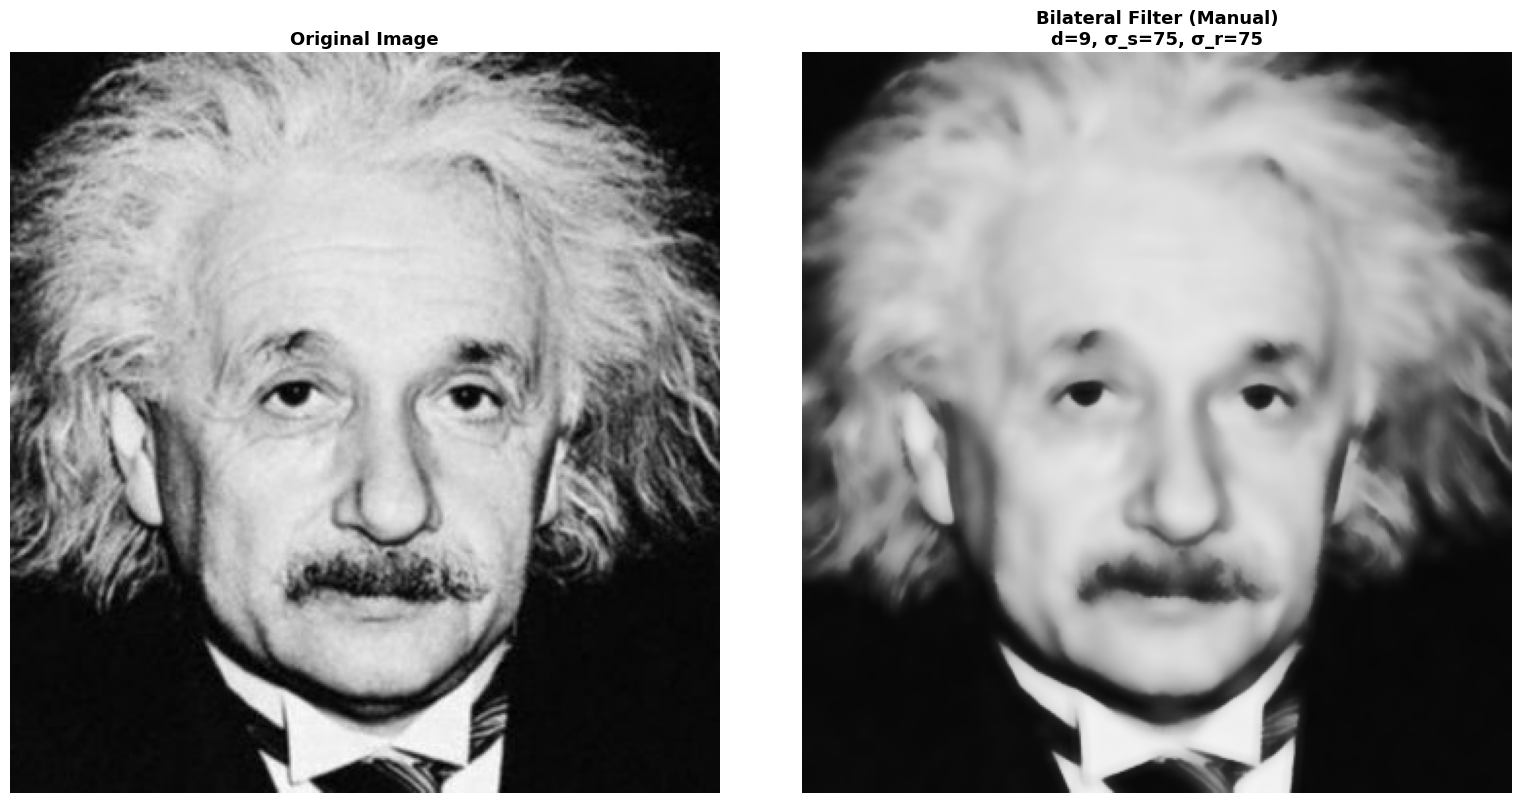

In [9]:
# Apply manual bilateral filter
print("Applying manual bilateral filter...")
print("This may take a few moments...\n")

img_bilateral_manual = bilateral_filter_manual(img, diameter=9, sigma_s=75, sigma_r=75)

print(f"\nManual bilateral filtered image size: {img_bilateral_manual.shape}")
print("Filtering complete!")

# Display result
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_bilateral_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Bilateral Filter (Manual)\nd=9, σ_s=75, σ_r=75', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## Compare All Methods

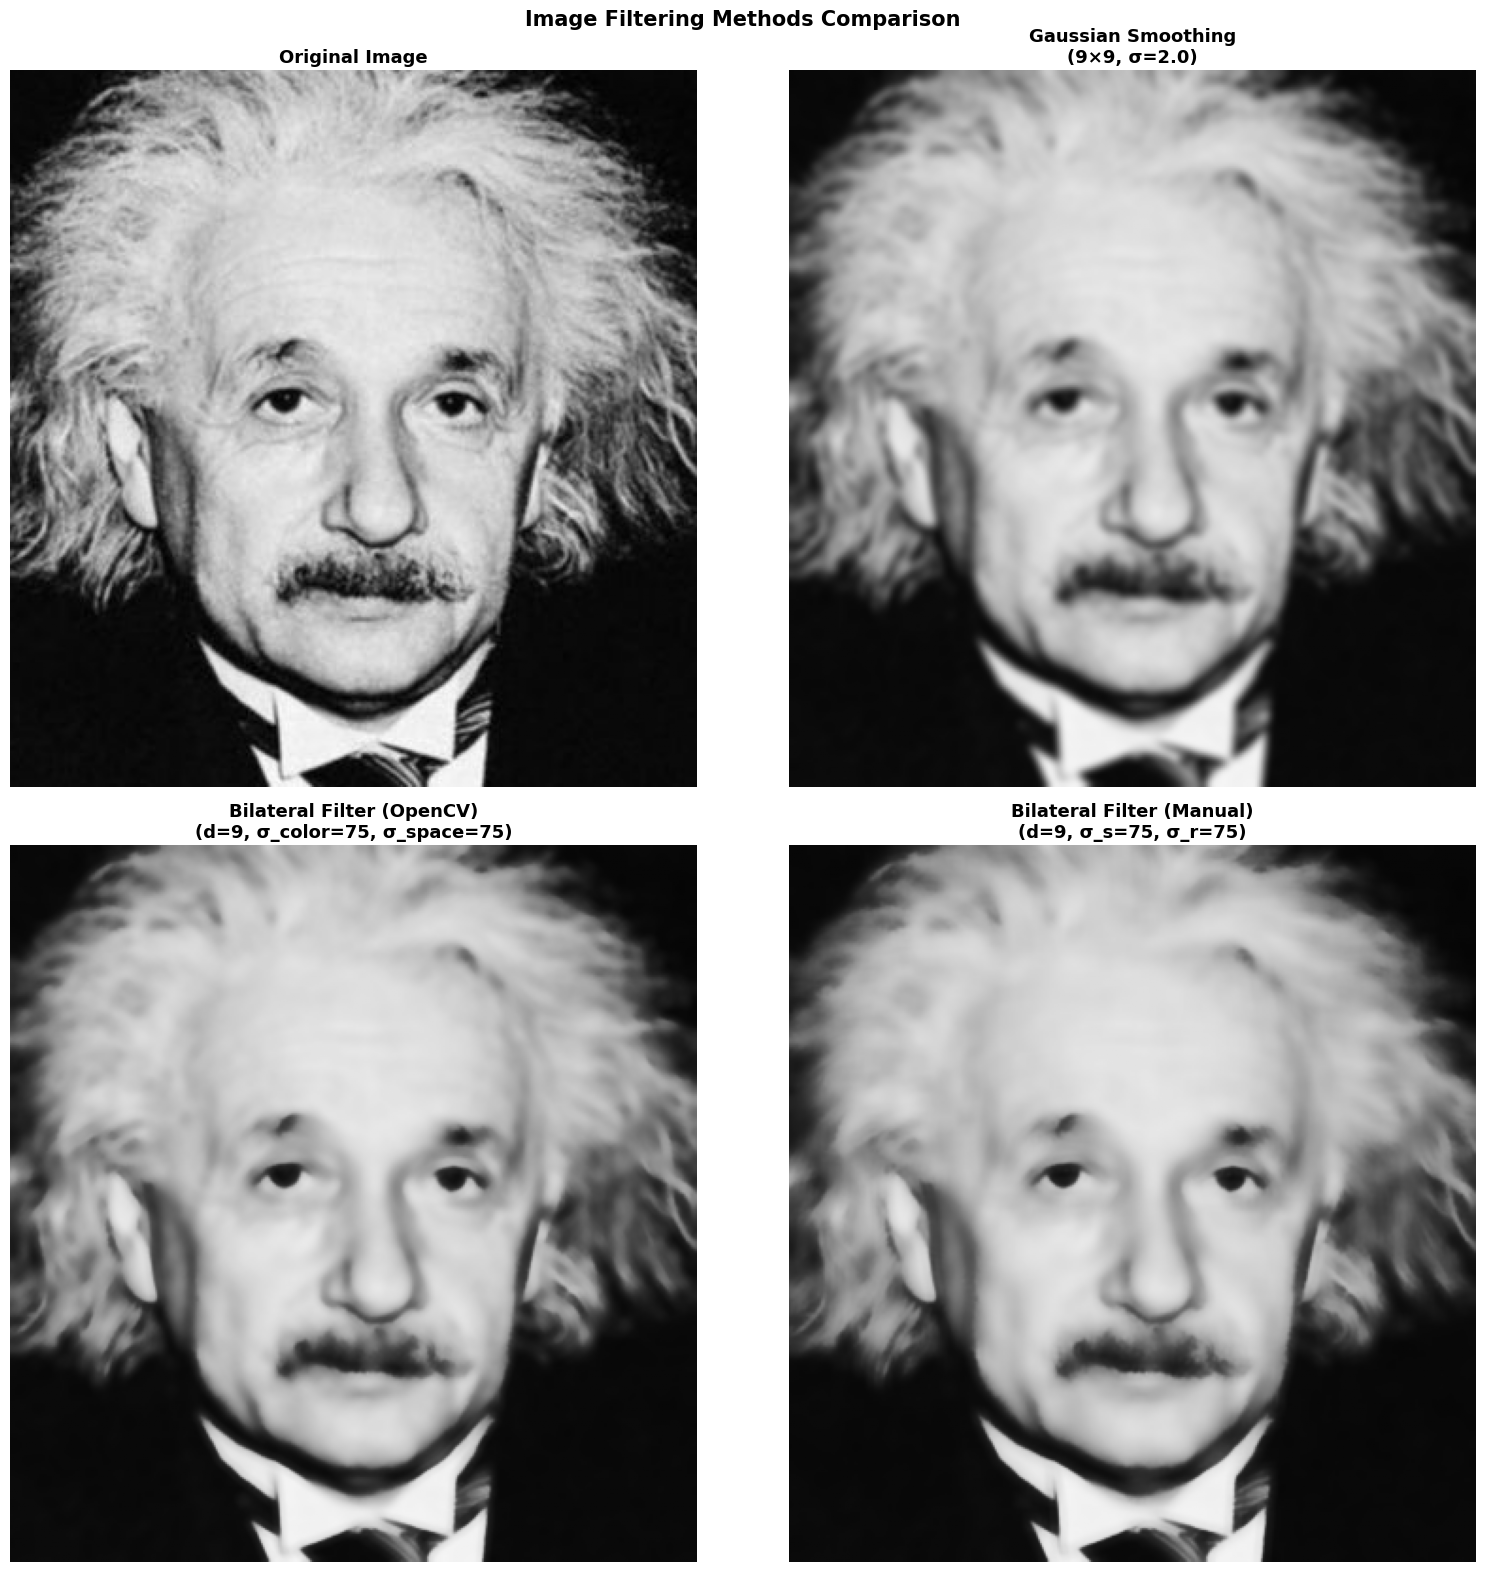

In [10]:
# Display all results together
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_gaussian, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Gaussian Smoothing\n(9×9, σ=2.0)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_bilateral_cv, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Bilateral Filter (OpenCV)\n(d=9, σ_color=75, σ_space=75)', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_bilateral_manual, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Bilateral Filter (Manual)\n(d=9, σ_s=75, σ_r=75)', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Image Filtering Methods Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
